# Competition No 01 : BDAIO Mock Competition 1

----

### Overview

The Bangladesh AI Olympiad (BDAIO) is right around the corner.
To help first-time participants get comfortable with the Kaggle workflow, we are hosting this simple mock regression challenge.

Your task: predict a participant's competition score based on how they prepared.

The dataset captures the preparation habits of 2,000 fictional BDAIO aspirants and their resulting scores. The relationship is intentionally straightforward - a perfect playground to practise the end-to-end ML pipeline without getting lost in complexity.

Take a look at a sample kaggle solution notebook: https://drive.google.com/file/d/1FABaX-gt9EbCbH29z6OXdp3OwDRddZn1/view?usp=sharing

Google Colab Version: https://colab.research.google.com/drive/1GcVNt7SAHTSGjCxtPjOeUCl91v5wEbME?usp=sharing

----
### Evaluation

Submissions are scored using Root Mean Squared Error (RMSE).

Lower RMSE = better score.


----
### Submission Format

Your submission file must have exactly two columns:

```text
id,score
5,42.31
9,67.88
...
```

Submit a CSV file with a header row. Predicted scores should be between 0 and 100.

----
### Where to Start

- Download the data files above.
- Open the Starter Notebook (solution_notebook.ipynb) — it covers EDA, modelling, and submission generation step by step.
- Try improving on the baseline: can you get a lower RMSE?

----
### Tips for First-Timers

- Read the data carefully before writing any code.
- Visualise - scatter plots and histograms tell you a lot.
- Cross-validate - don't just trust your training score.
- Clip predictions to [0, 100] - scores can't be negative or over 100!
- Iterate fast - submit early, then improve.

----
### Leaderboard

This is a public practice round — the leaderboard is for learning, not ranking.
Don't be afraid to submit multiple times and see how your RMSE changes.

Good luck, and may your RMSE be low! 

## 01 Importing Libreries

In [1]:
# libreries loading :
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 02 Loading Datasets

In [2]:
# data loading :
train = pd.read_csv('/kaggle/input/competitions/bdaio-mock-competition-1/train.csv')
test = pd.read_csv('/kaggle/input/competitions/bdaio-mock-competition-1/test.csv')
samp = pd.read_csv('/kaggle/input/competitions/bdaio-mock-competition-1/sample_submission.csv')

## 03 Exploratory Data Analysis

In [3]:
train.shape

(1600, 5)

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             1600 non-null   int64  
 1   kaggle_hours   1600 non-null   float64
 2   mock_contests  1600 non-null   int64  
 3   study_days     1600 non-null   int64  
 4   score          1600 non-null   float64
dtypes: float64(2), int64(3)
memory usage: 62.6 KB


In [5]:
train.describe()

,id,kaggle_hours,mock_contests,study_days,score
count,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000
mean,991.548125,59.657250,3.970625,10.156250,42.184056
std,580.467603,35.347805,2.603171,5.966392,19.727635
min,1.000000,0.400000,0.000000,0.000000,0.000000
25%,482.500000,28.475000,2.000000,5.000000,25.895000
50%,986.000000,60.800000,4.000000,10.000000,42.865000
75%,1492.250000,90.325000,6.000000,15.000000,57.722500
max,2000.000000,120.000000,8.000000,20.000000,100.000000


In [6]:
train.isna().sum()

id               0
kaggle_hours     0
mock_contests    0
study_days       0
score            0
dtype: int64

In [7]:
train

,id,kaggle_hours,mock_contests,study_days,score
0,915,66.2,1,20,46.01
1,11,2.5,3,2,9.56
2,720,87.7,3,8,52.18
3,1132,59.5,3,2,35.97
4,1603,27.2,0,8,21.90
...,...,...,...,...,...
1595,1479,95.7,2,14,79.01
1596,1504,40.9,1,10,24.63
1597,1188,8.1,0,11,6.04
1598,979,59.6,4,0,35.31


In [8]:
test

,id,kaggle_hours,mock_contests,study_days
0,579,59.1,4,10
1,1774,114.6,2,14
2,777,27.5,7,5
3,590,18.2,0,16
4,1693,47.8,0,5
...,...,...,...,...
395,513,111.9,5,7
396,395,40.9,1,16
397,1632,41.7,1,6
398,294,43.2,3,19


In [9]:
samp

,id,score
0,579,0.0
1,1774,0.0
2,777,0.0
3,590,0.0
4,1693,0.0
...,...,...
395,513,0.0
396,395,0.0
397,1632,0.0
398,294,0.0


## **04 Data Visualization**

---
### **Lineplot**

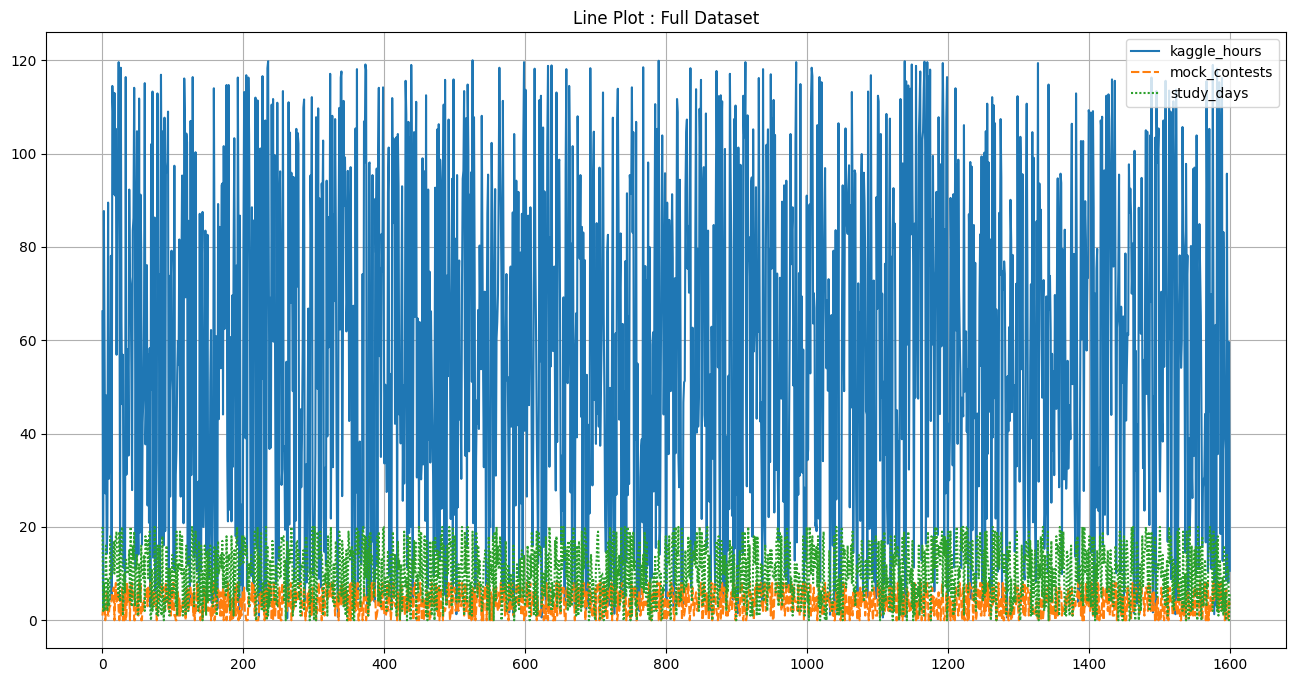

In [10]:
# it doesnt make sens any thing .
plt.figure(figsize=(16, 8))

plt.title('Line Plot : Full Dataset')

sns.lineplot(train.drop(columns=['id', 'score']))
plt.grid(True)
plt.show()

****This doesn't make any sense.****

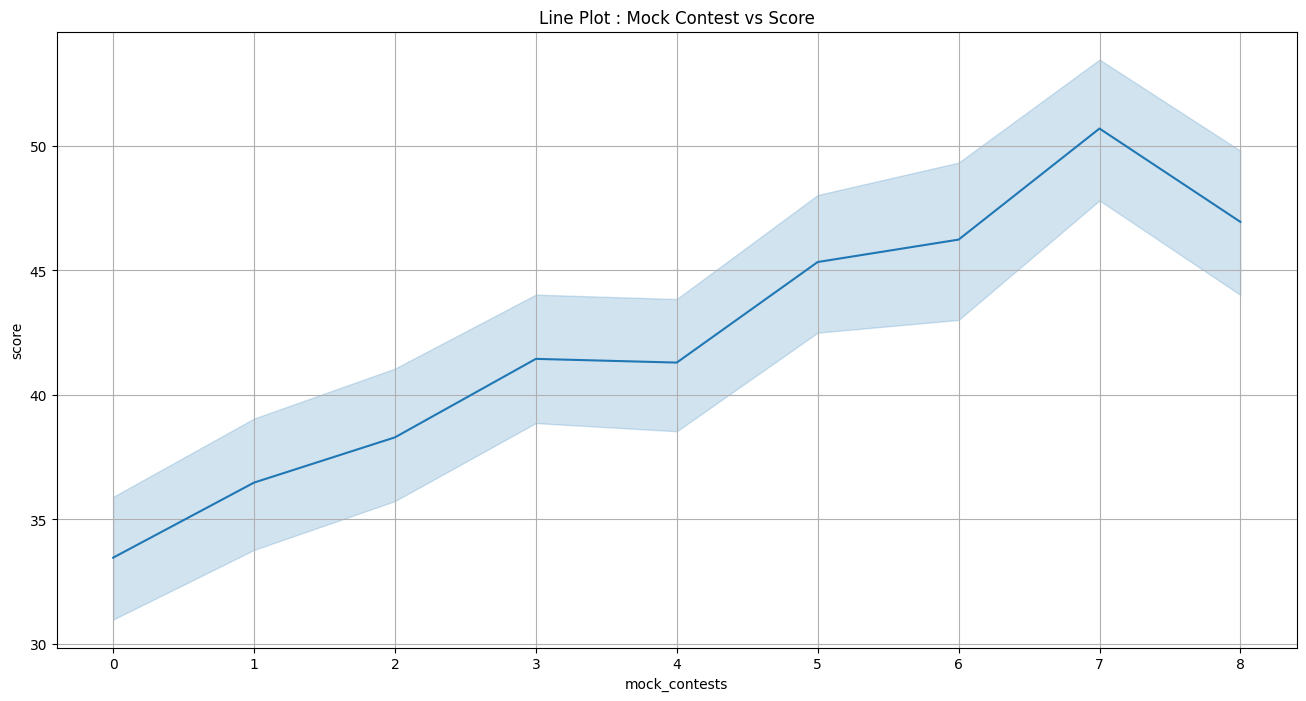

In [11]:
plt.figure(figsize=(16, 8))

plt.title('Line Plot : Mock Contest vs Score')

sns.lineplot(train, x='mock_contests', y='score')
plt.grid(True)
plt.show()

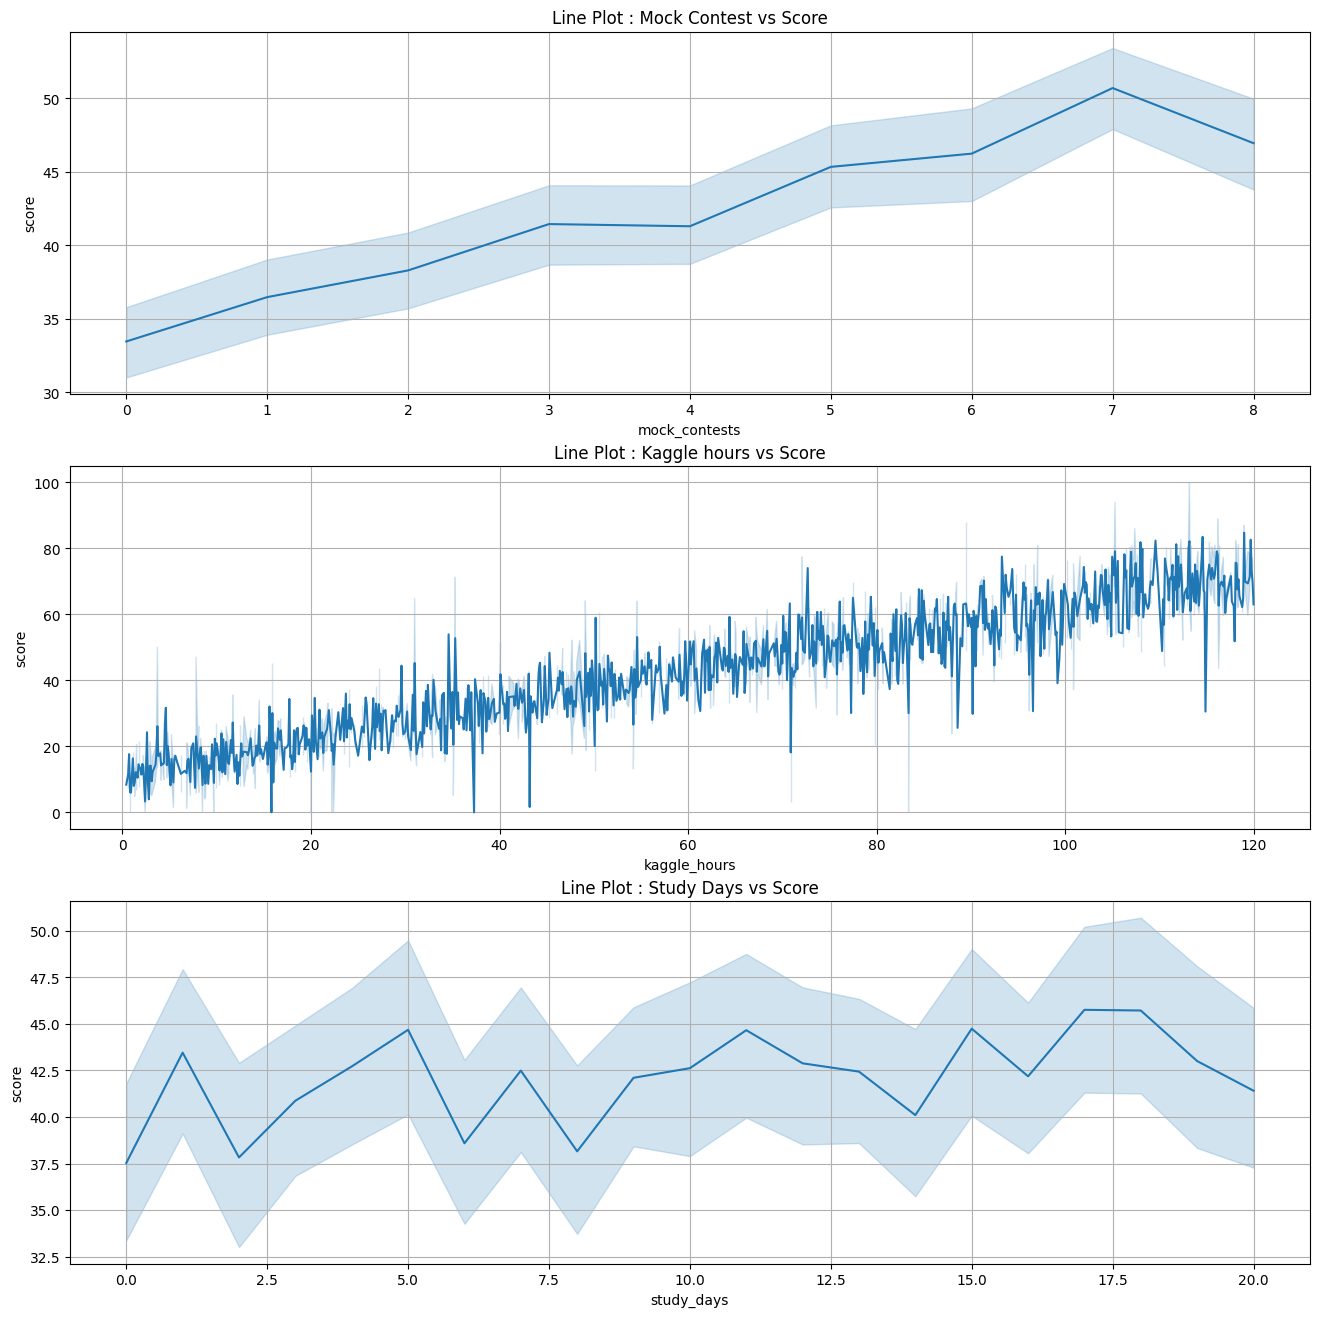

In [12]:
plt.figure(figsize=(16, 16))

plt.subplot(3, 1, 1)
plt.title('Line Plot : Mock Contest vs Score')
sns.lineplot(train, x='mock_contests', y='score')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.title('Line Plot : Kaggle hours vs Score')
sns.lineplot(train, x='kaggle_hours', y='score')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.title('Line Plot : Study Days vs Score')
sns.lineplot(train, x='study_days', y='score')
plt.grid(True)

plt.show()

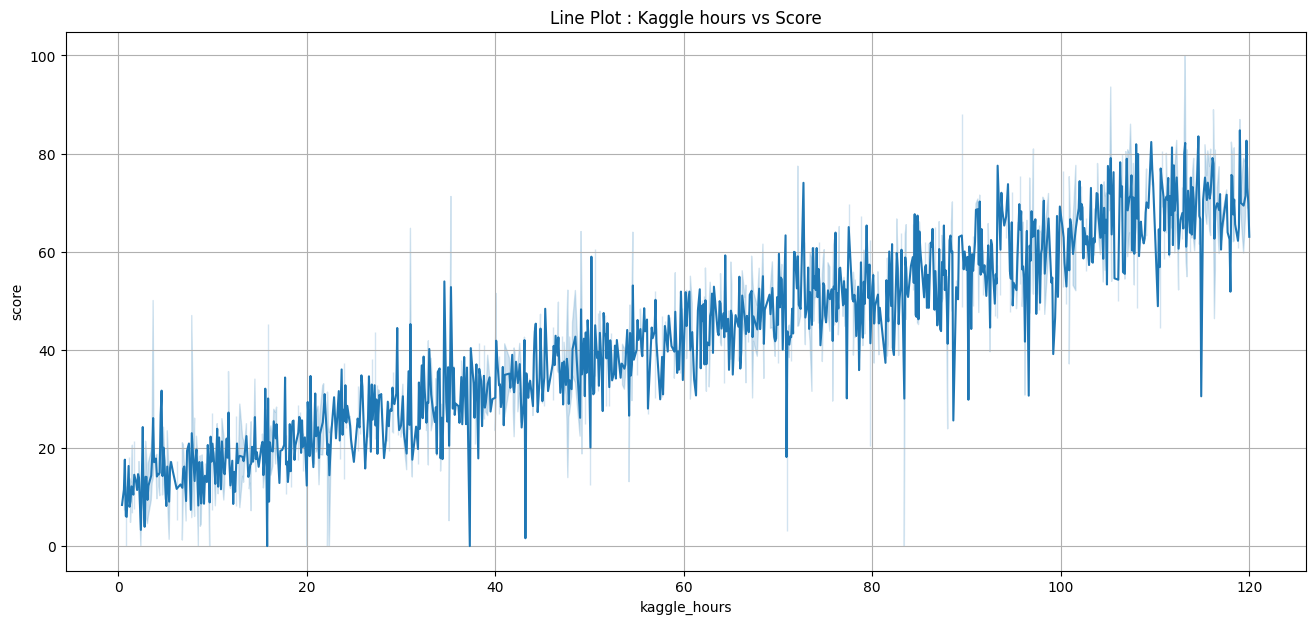

In [13]:
plt.figure(figsize=(16, 7))

plt.title('Line Plot : Kaggle hours vs Score')
sns.lineplot(train, x='kaggle_hours', y='score')

plt.grid(True)

----
### **Scatter Plot**

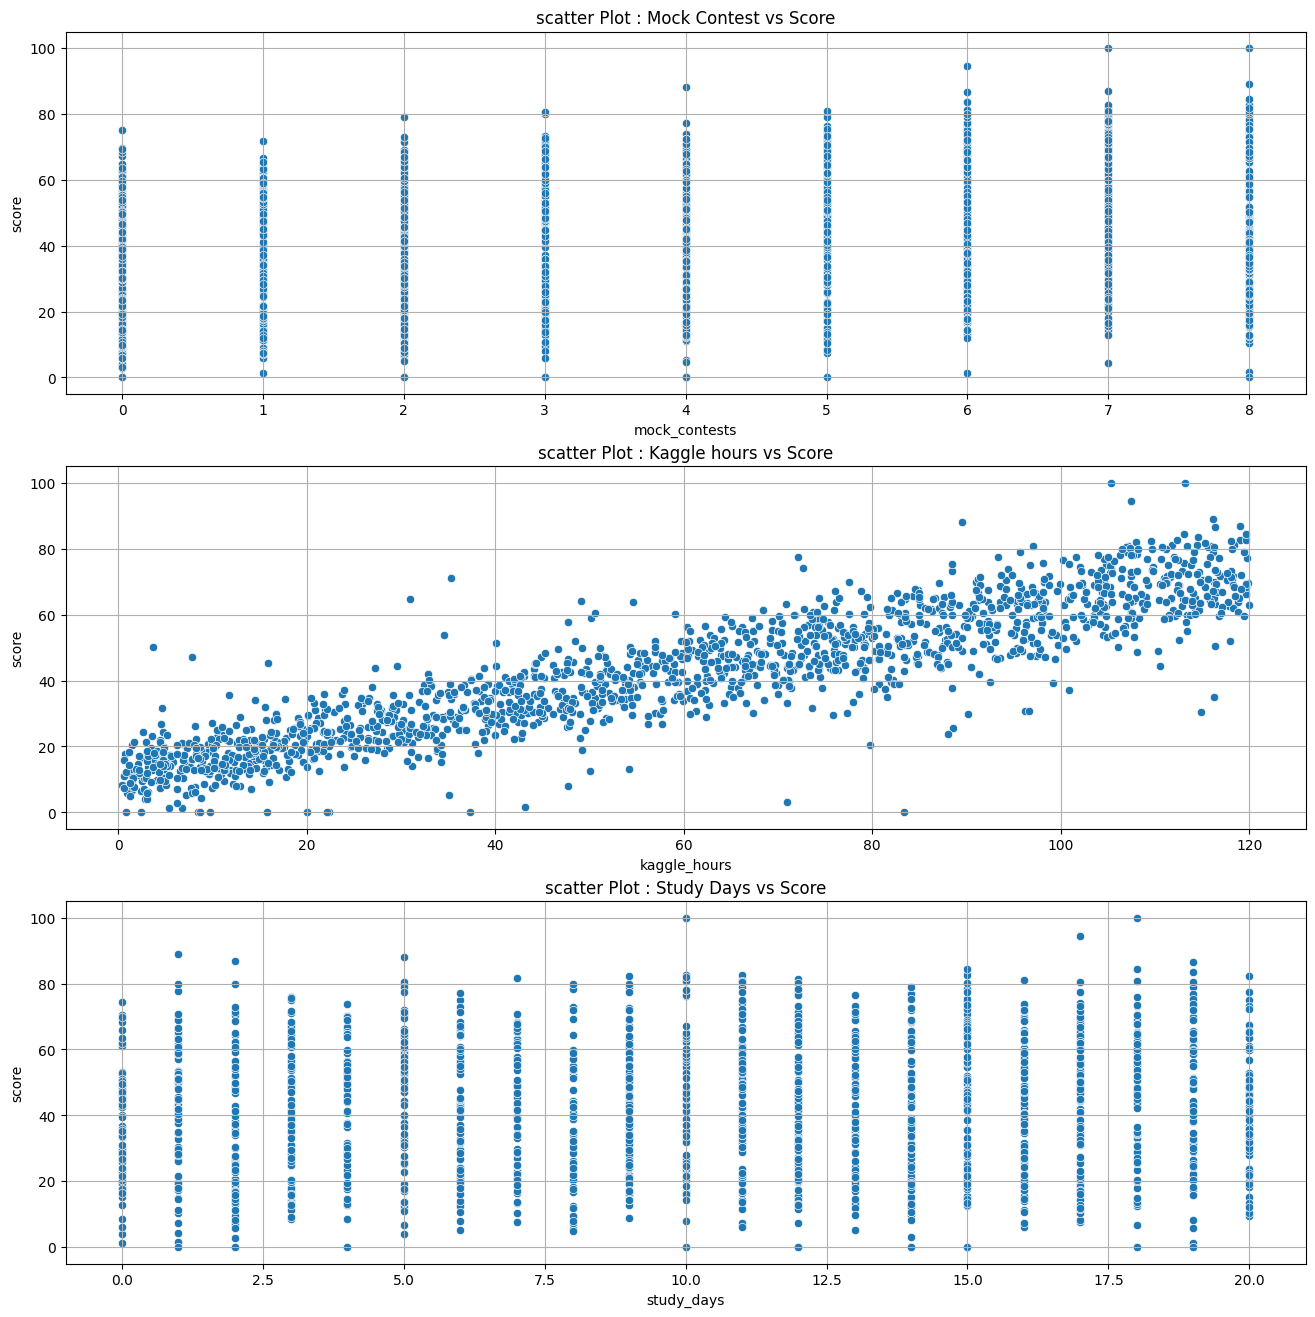

In [14]:
plt.figure(figsize=(16, 16))

plt.subplot(3, 1, 1)
plt.title('scatter Plot : Mock Contest vs Score')
sns.scatterplot(train, x='mock_contests', y='score')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.title('scatter Plot : Kaggle hours vs Score')
sns.scatterplot(train, x='kaggle_hours', y='score')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.title('scatter Plot : Study Days vs Score')
sns.scatterplot(train, x='study_days', y='score')
plt.grid(True)

plt.show()

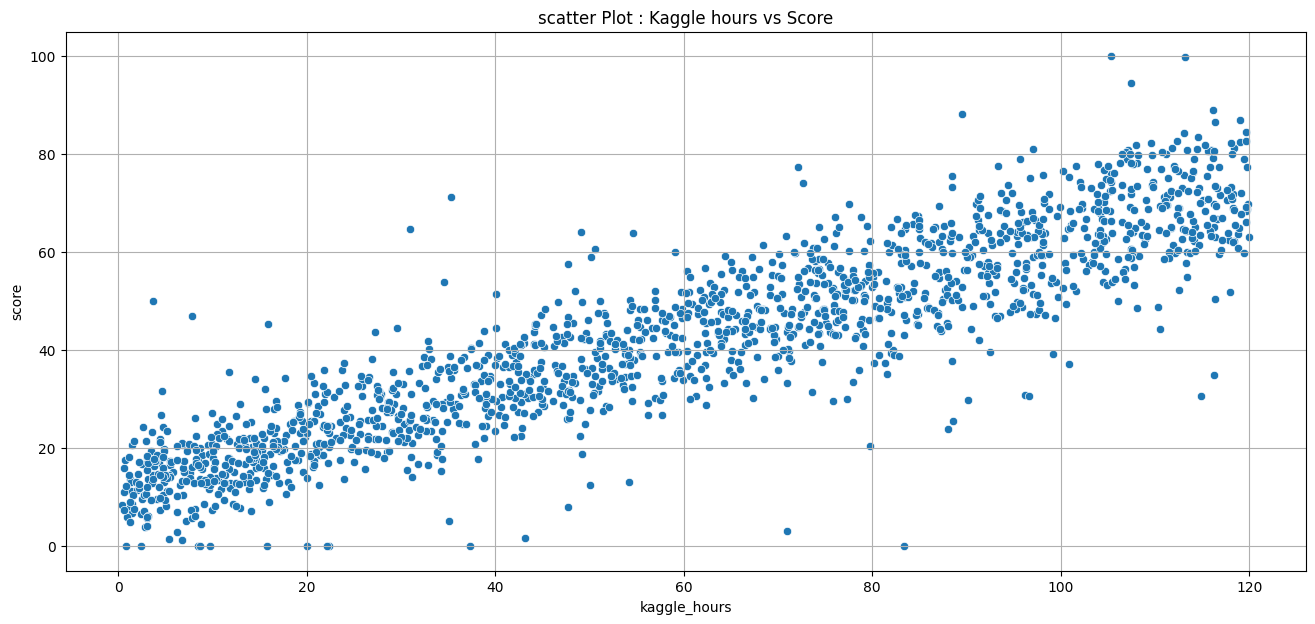

In [15]:
plt.figure(figsize=(16, 7))

plt.title('scatter Plot : Kaggle hours vs Score')
sns.scatterplot(train, x='kaggle_hours', y='score')

plt.grid(True)

---
### **Histogram**

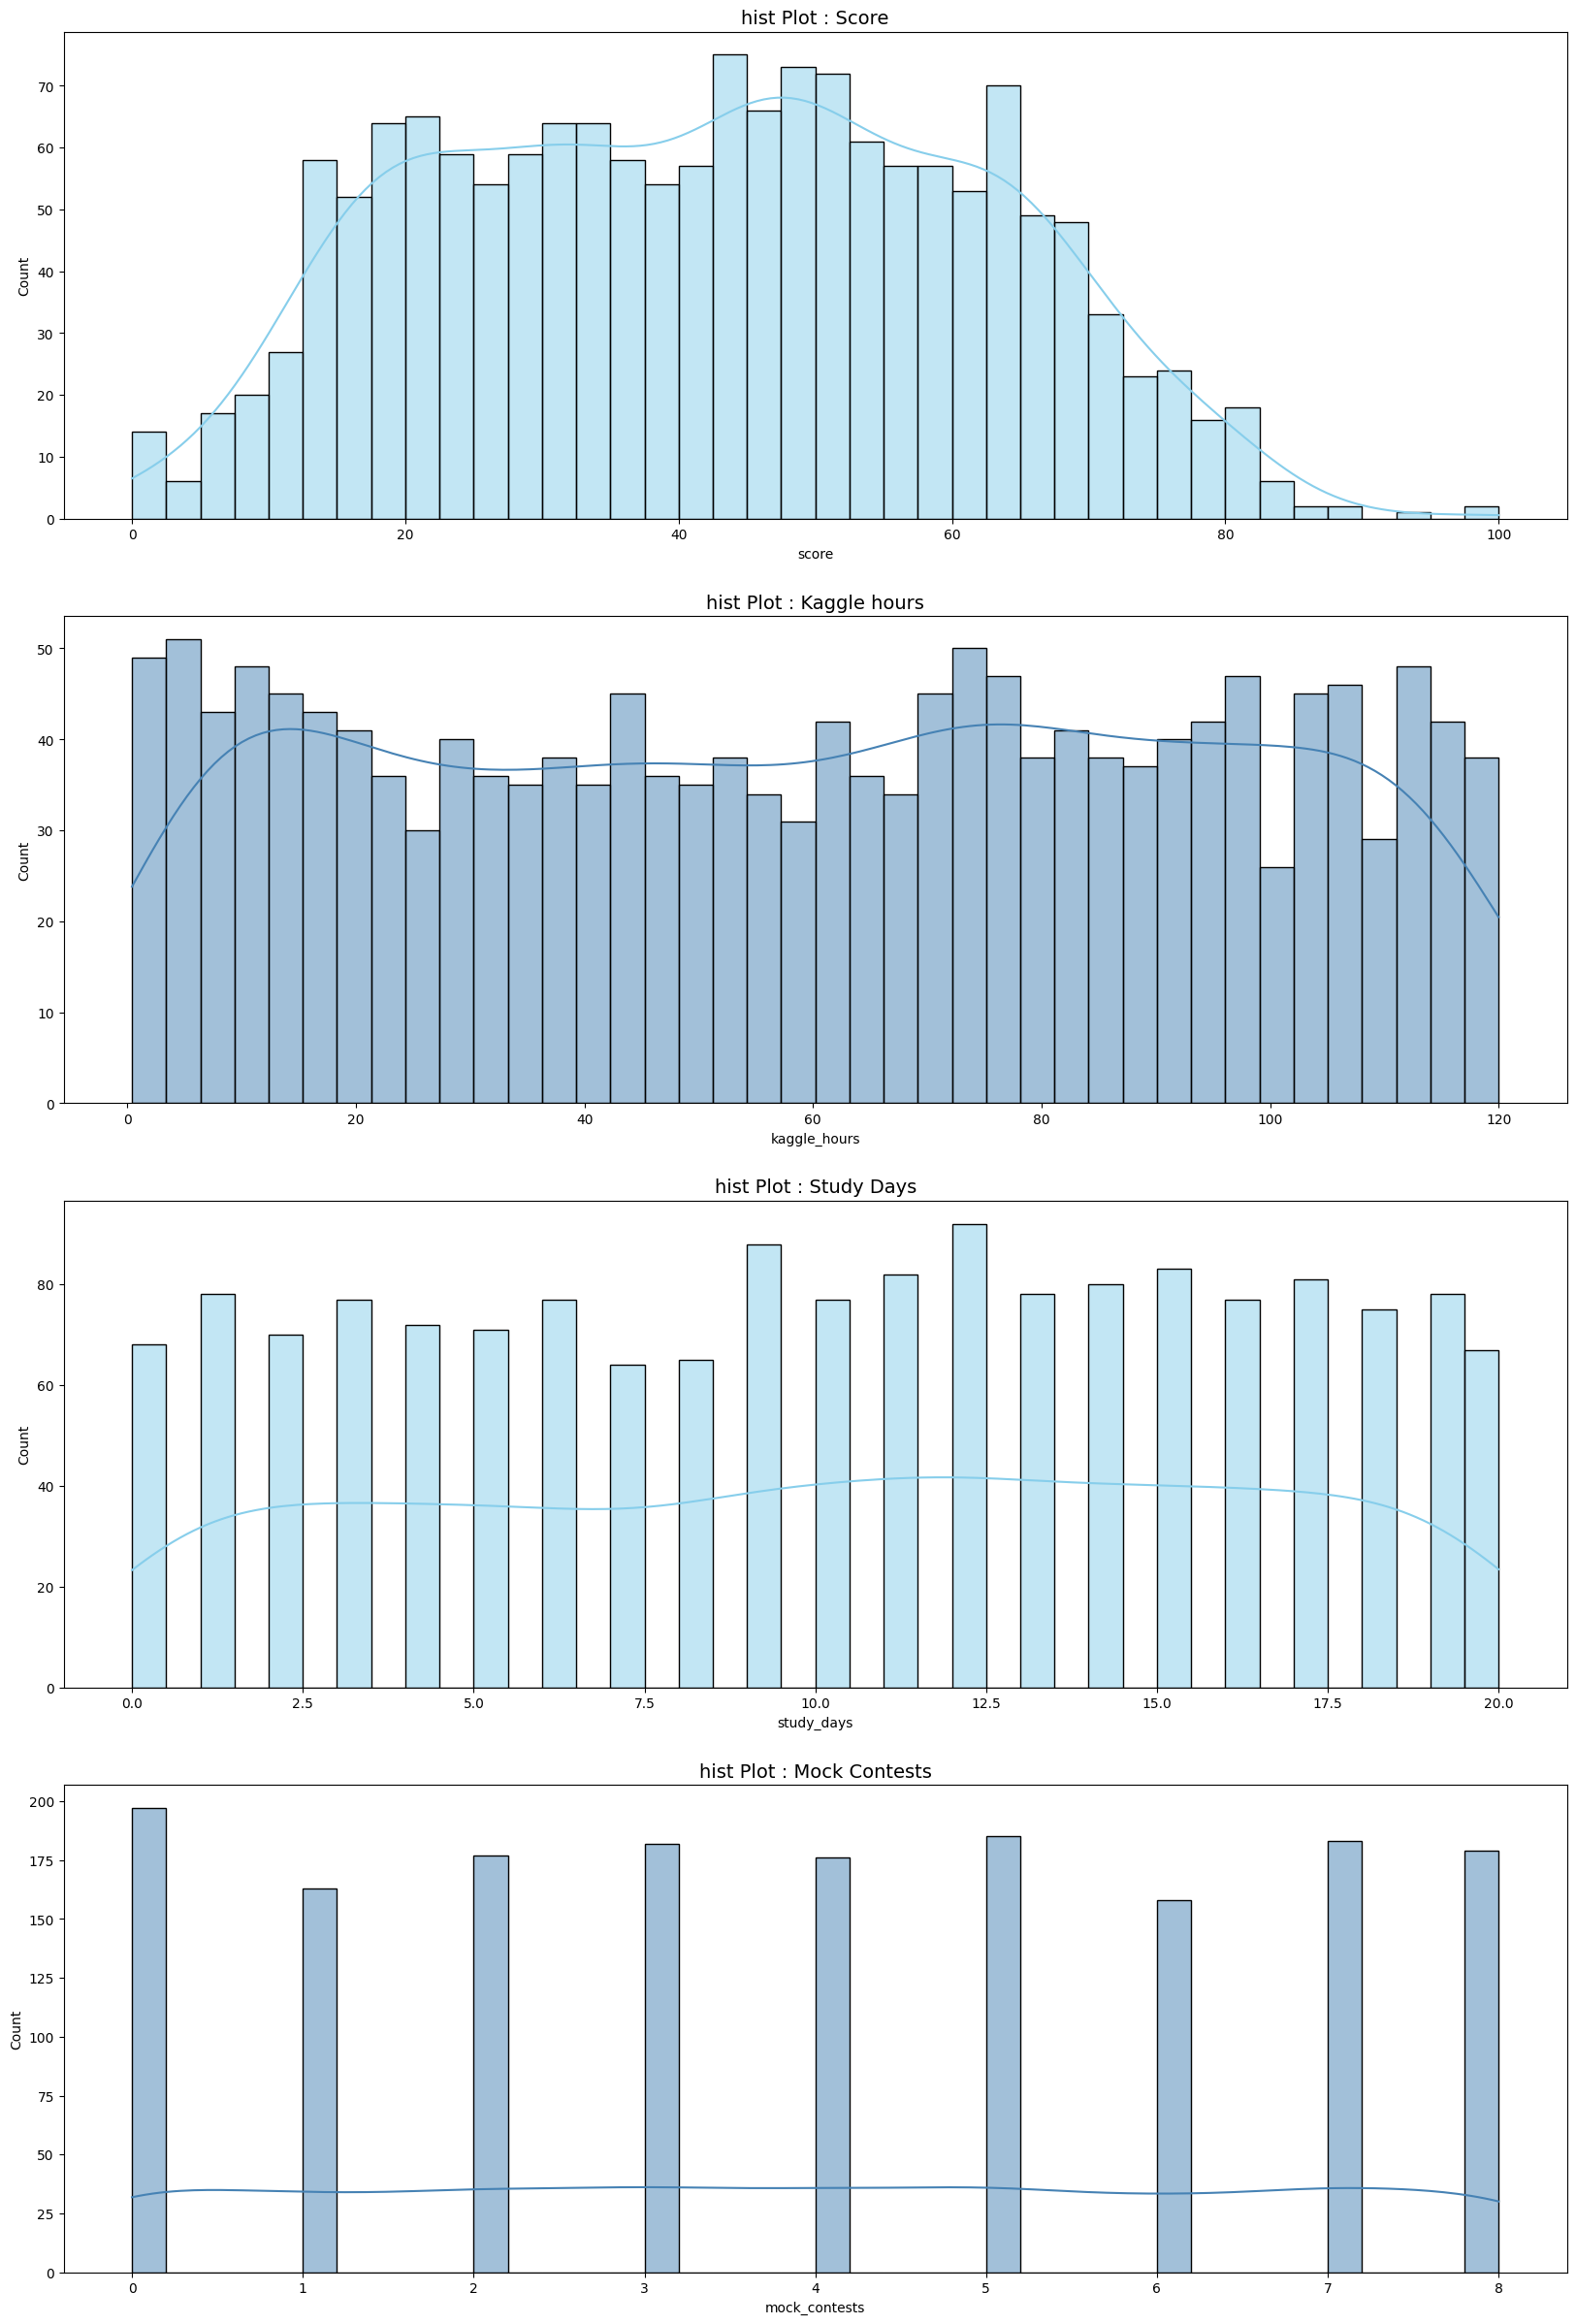

In [16]:
plt.figure(figsize=(20, 30))

plt.subplot(4, 1, 1)
plt.title('hist Plot : Score', fontsize=14)
sns.histplot(train['score'], bins= 40, fill=True, kde=True, color='skyblue')

plt.subplot(4, 1, 2)
plt.title('hist Plot : Kaggle hours', fontsize=14)
sns.histplot(train['kaggle_hours'], bins= 40, fill=True, kde=True, color='steelblue')

plt.subplot(4, 1, 3)
plt.title('hist Plot : Study Days', fontsize=14)
sns.histplot(train['study_days'], bins= 40, fill=True, kde=True, color='skyblue')

plt.subplot(4, 1, 4)
plt.title('hist Plot : Mock Contests', fontsize=14)
sns.histplot(train['mock_contests'], bins= 40, fill=True, kde=True, color='steelblue')

plt.show()

---
### Kde Plot / Probability Distribution Function

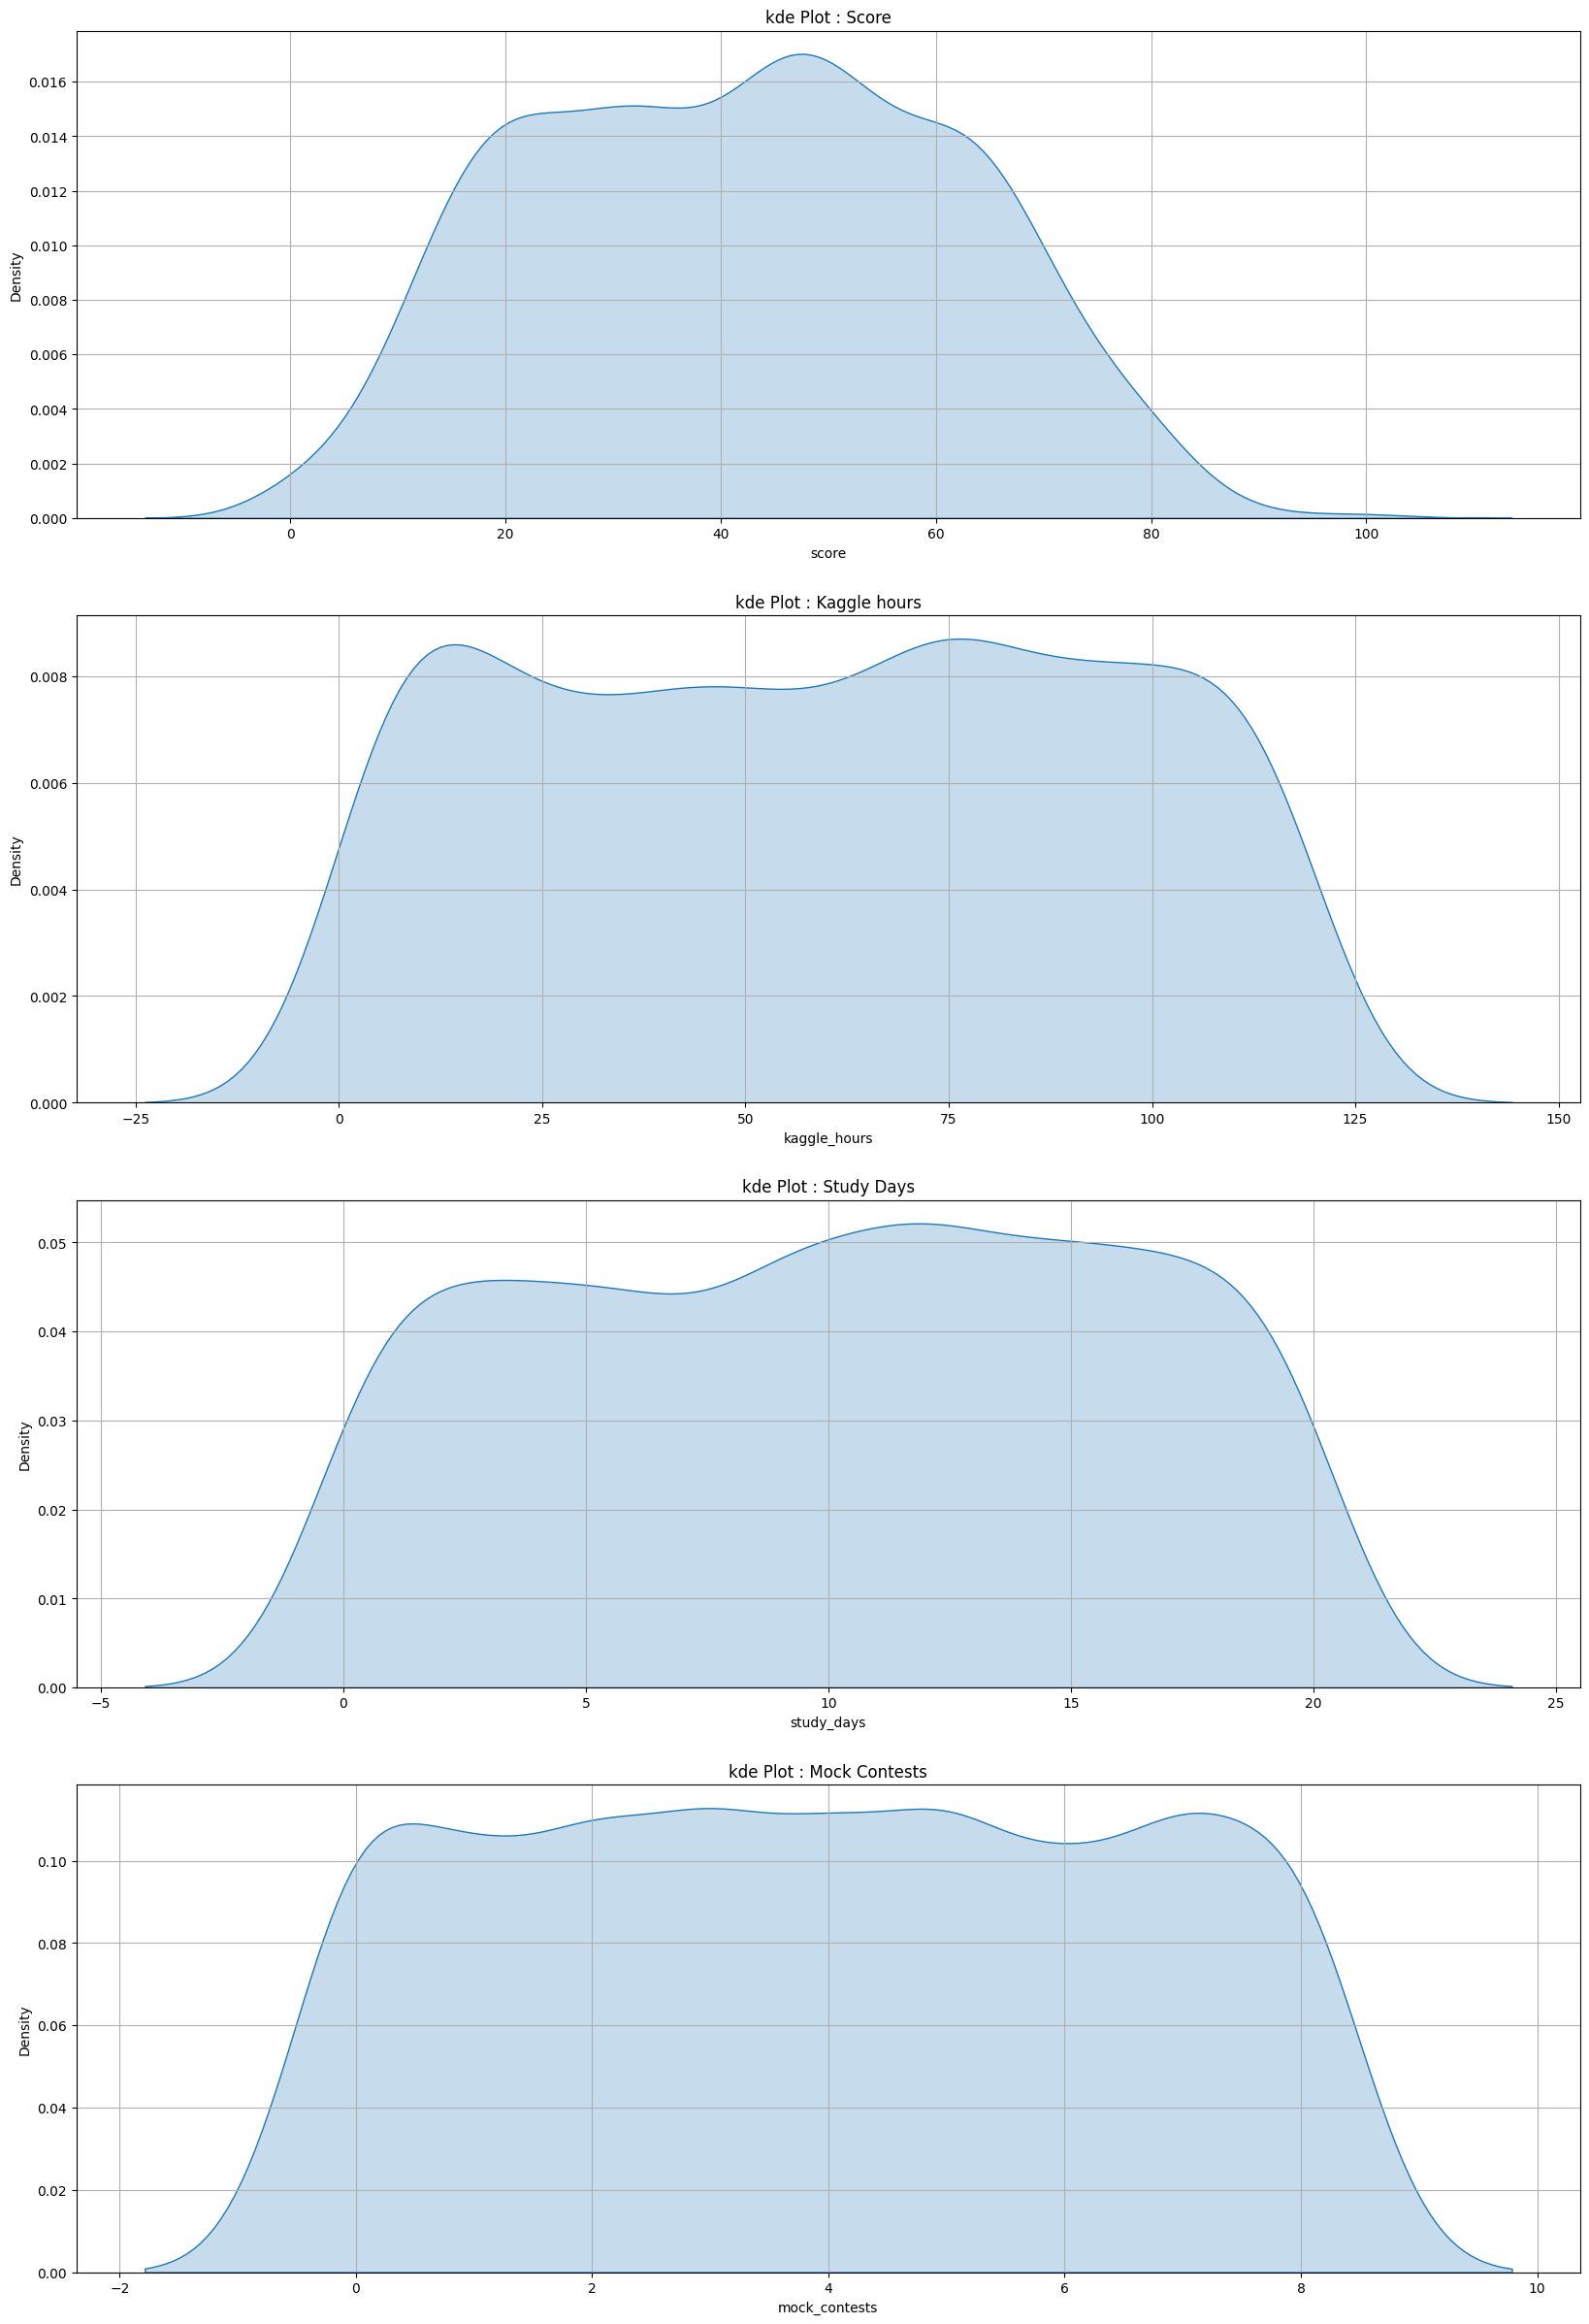

In [17]:
plt.figure(figsize=(20, 30))

plt.subplot(4, 1, 1)
plt.title('kde Plot : Score')
sns.kdeplot(train['score'], fill=True)
plt.grid(True)

plt.subplot(4, 1, 2)
plt.title('kde Plot : Kaggle hours')
sns.kdeplot(train['kaggle_hours'], fill=True)
plt.grid(True)

plt.subplot(4, 1, 3)
plt.title('kde Plot : Study Days')
sns.kdeplot(train['study_days'], fill=True)
plt.grid(True)

plt.subplot(4, 1, 4)
plt.title('kde Plot : Mock Contests')
sns.kdeplot(train['mock_contests'], fill=True)
plt.grid(True)

plt.show()

---
### Joint Plot

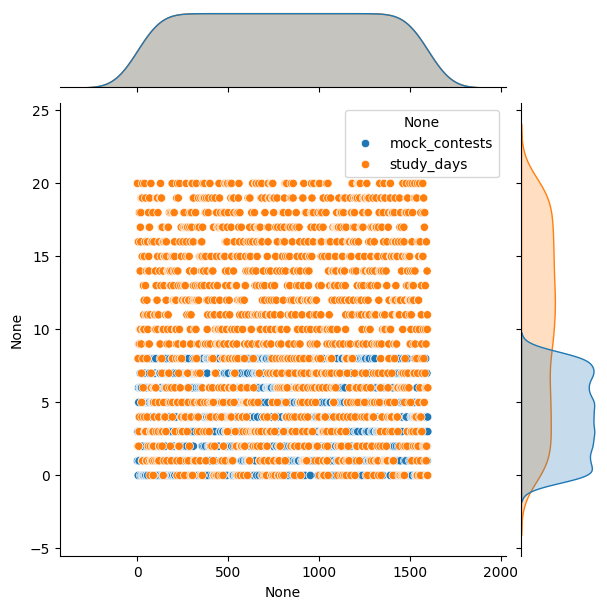

In [18]:

sns.jointplot(train.drop(columns=['id', 'score', 'kaggle_hours']))

plt.show()

**I dont understand anything by this plot.**

---

### Bar Plot

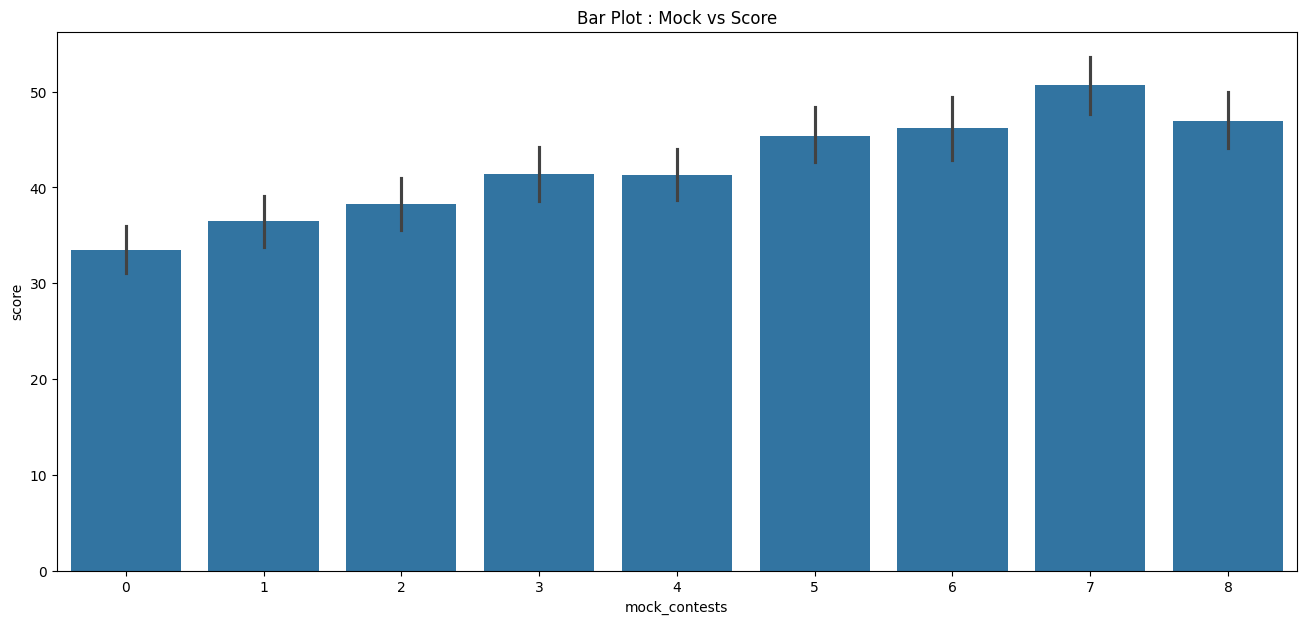

In [19]:
plt.figure(figsize=(16, 7))

plt.title('Bar Plot : Mock vs Score')
sns.barplot(train, x='mock_contests', y='score')

plt.show()

### Box Plot

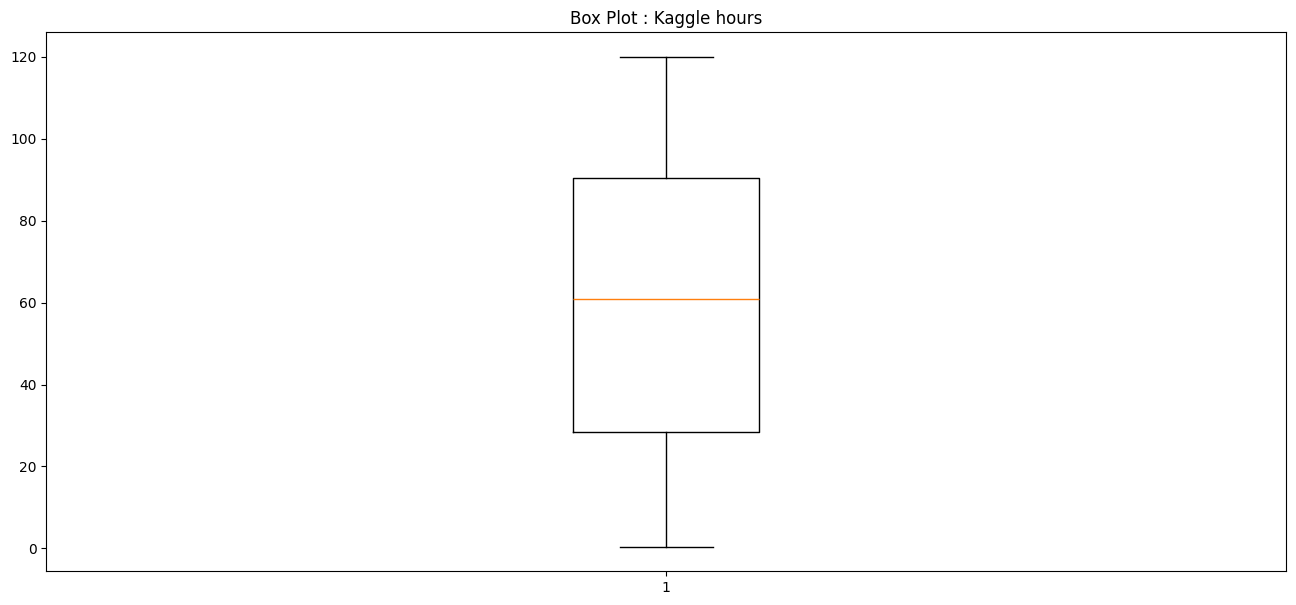

In [20]:
plt.figure(figsize=(16, 7))

plt.title('Box Plot : Kaggle hours')
plt.boxplot(train.kaggle_hours)

plt.show()

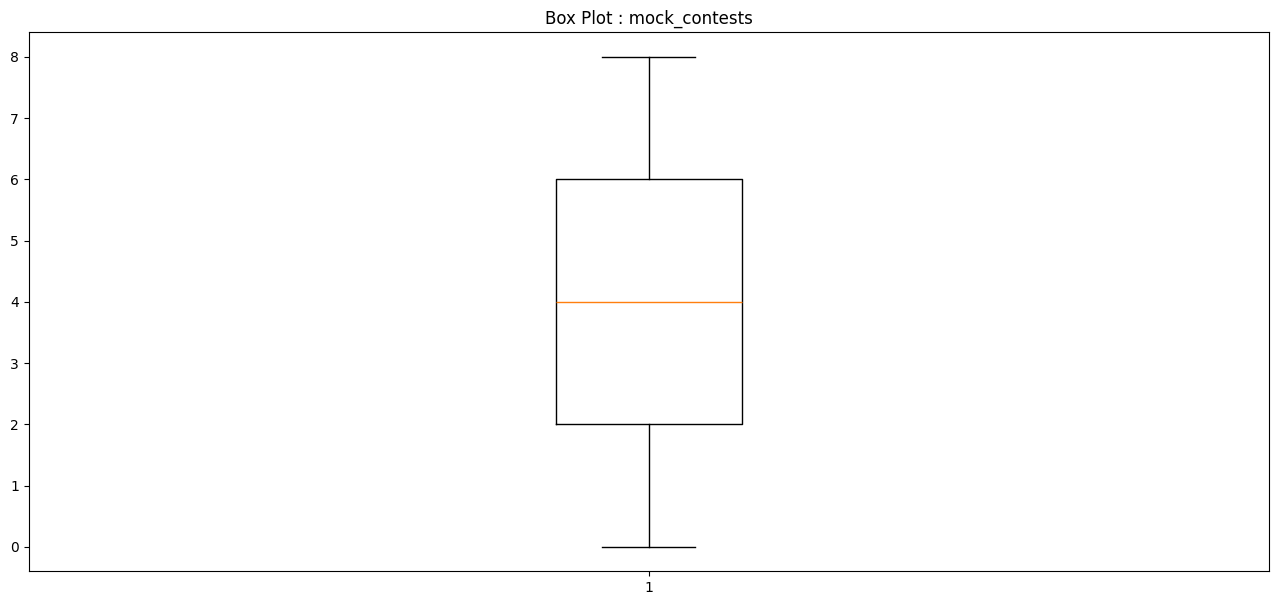

In [21]:
plt.figure(figsize=(16, 7))

plt.title('Box Plot : mock_contests')
plt.boxplot(train.mock_contests)

plt.show()

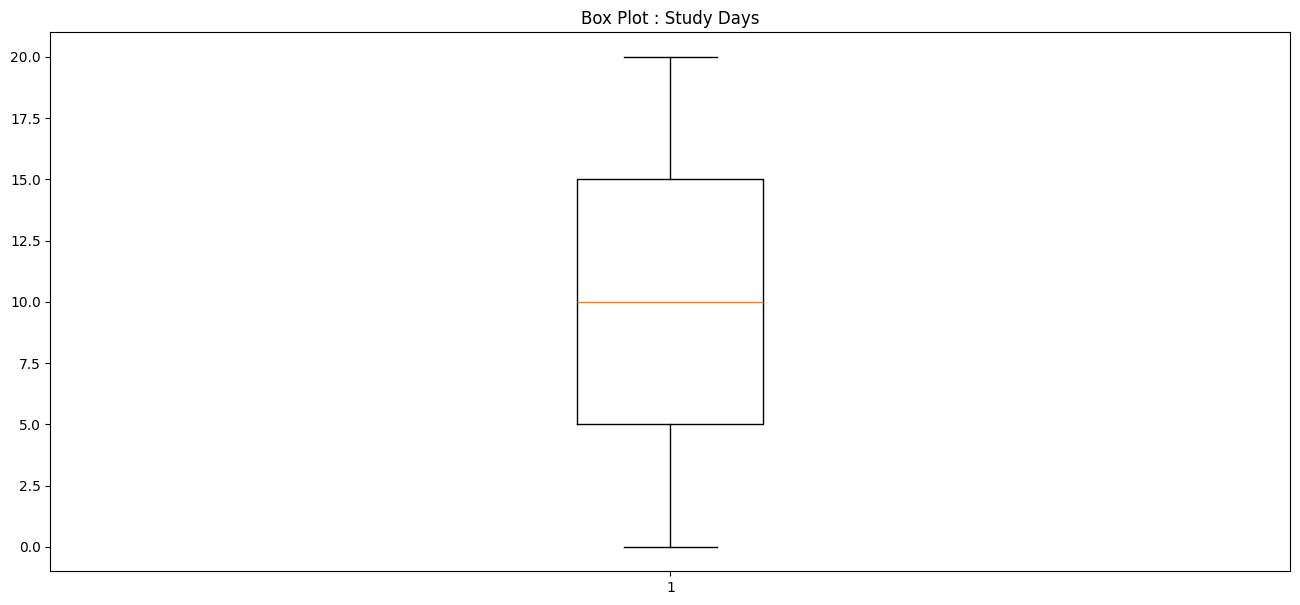

In [22]:
plt.figure(figsize=(16, 7))

plt.title('Box Plot : Study Days')
plt.boxplot(train.study_days)

plt.show()

**So there is no Outlier in these features.**

### Heatmap

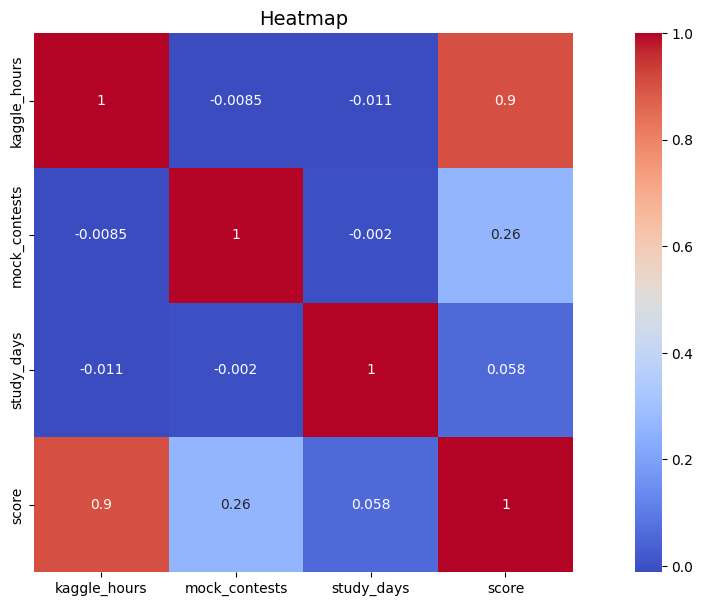

In [23]:
plt.figure(figsize=(16, 7))

plt.title('Heatmap', fontsize=14)
sns.heatmap(data=train.drop(columns='id').corr(), cmap='coolwarm', square=True, annot=True)

# plt.tight_layout()
plt.show()

****This doesn't make any sense.****

----
## 05 Preprocessing Data

---
### Feature and Target Separation

In [24]:
X = train.drop(columns=['id','score'])
y = train['score']
test = test.drop(columns='id')

----
### Normalization or Standardization

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_train = scaler.fit_transform(X)
scaled_test  = scaler.fit_transform(test)

scaled_train.shape , scaled_test.shape

((1600, 3), (400, 3))

---
### Normalization by MinMaxScaler

In [26]:
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()

minmaxed_train = minmax.fit_transform(X)
minmaxed_test = minmax.fit_transform(test)

minmaxed_train.shape, minmaxed_test.shape

((1600, 3), (400, 3))

### Dataset Splitting 

In [27]:
from sklearn.model_selection import train_test_split as tts

# with out scaler
X_train, X_val, y_train, y_val = tts(X, y, test_size=0.2, random_state=19)

# standard scaler
X_std_train, X_std_val, y_std_train, y_std_val = tts(scaled_train, y, test_size=0.2, random_state=19)

# minmaxscaler
X_mms_train, X_mms_val, y_mms_train, y_mms_val = tts(minmaxed_train, y, test_size=0.2, random_state=19)

print(f'Train Dataset size : {(len(X_std_train) / len(X)) * 100}%')
print(f'Test  Dataset size : {(len(X_std_val) / len(X)) *100}%')

Train Dataset size : 80.0%
Test  Dataset size : 20.0%


---
## 06 Model Creation

----
### Linear Regression

In [28]:
from sklearn.linear_model import LinearRegression

model_ln = LinearRegression()

# prediction without any scaler :
model_ln.fit(X_train, y_train)
ln_pred_no_scaler = model_ln.predict(X_val)

# prediction with standard scaler :
model_ln.fit(X_std_train, y_std_train)
ln_pred_std_scaler = model_ln.predict(X_std_val)

# prediction with standard scaler :
model_ln.fit(X_mms_train, y_mms_train)
ln_pred_mms_scaler = model_ln.predict(X_mms_val)

----
### Ridge Regression

In [29]:
from sklearn.linear_model import Ridge

model_rg = Ridge()

# prediction without any scaler :
model_rg.fit(X_train, y_train)
rg_pred_no_scaler = model_rg.predict(X_val)

# prediction with standard scaler :
model_rg.fit(X_std_train, y_std_train)
rg_pred_std_scaler = model_rg.predict(X_std_val)

# prediction with standard scaler :
model_rg.fit(X_mms_train, y_mms_train)
rg_pred_mms_scaler = model_rg.predict(X_mms_val)

---
## 07 Model Evaluation

In [30]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error

print('Evaluation on Validation Datasets : Linear Regression')
print(f'{"":4s}Without any scler :')
print(f'{"":8s}MAE : ', mean_absolute_error(y_val, ln_pred_no_scaler), '\n')

print(f'{"":4s}With Standard scler :')
print(f'{"":8s}MAE : ', mean_absolute_error(y_val, ln_pred_std_scaler), '\n')

print(f'{"":4s}With MinMax scler :')
print(f'{"":8s}MAE : ', mean_absolute_error(y_val, ln_pred_mms_scaler), '\n')

print()

print(f'{"":4s}Without any scler :')
print(f'{"":8s}MSE : ', mean_squared_error(y_val, ln_pred_no_scaler), '\n')

print(f'{"":4s}With Standard scler :')
print(f'{"":8s}MSE : ', mean_squared_error(y_val, ln_pred_std_scaler), '\n')

print(f'{"":4s}With MinMax scler :')
print(f'{"":8s}MSE : ', mean_squared_error(y_val, ln_pred_mms_scaler), '\n')


print()

print(f'{"":4s}Without any scler :')
print(f'{"":8s}RMSE : ', root_mean_squared_error(y_val, ln_pred_no_scaler), '\n')

print(f'{"":4s}With Standard scler :')
print(f'{"":8s}RMSE : ', root_mean_squared_error(y_val, ln_pred_std_scaler), '\n')

print(f'{"":4s}With MinMax scler :')
print(f'{"":8s}RMSE : ', root_mean_squared_error(y_val, ln_pred_mms_scaler), '\n')

Evaluation on Validation Datasets : Linear Regression
    Without any scler :
        MAE :  4.555852216951471 

    With Standard scler :
        MAE :  4.555852216951472 

    With MinMax scler :
        MAE :  4.555852216951469 


    Without any scler :
        MSE :  54.966540182652366 

    With Standard scler :
        MSE :  54.96654018265237 

    With MinMax scler :
        MSE :  54.96654018265234 


    Without any scler :
        RMSE :  7.413942283471889 

    With Standard scler :
        RMSE :  7.413942283471889 

    With MinMax scler :
        RMSE :  7.413942283471887 



In [31]:
print('Evaluation on Validation Datasets : Ridge Regression')
print(f'{"":4s}Without any scler :')
print(f'{"":8s}MAE : ', mean_absolute_error(y_val, rg_pred_no_scaler), '\n')

print(f'{"":4s}With Standard scler :')
print(f'{"":8s}MAE : ', mean_absolute_error(y_val, rg_pred_std_scaler), '\n')

print(f'{"":4s}With MinMax scler :')
print(f'{"":8s}MAE : ', mean_absolute_error(y_val, rg_pred_mms_scaler), '\n')

print()

print(f'{"":4s}Without any scler :')
print(f'{"":8s}MSE : ', mean_squared_error(y_val, rg_pred_no_scaler), '\n')

print(f'{"":4s}With Standard scler :')
print(f'{"":8s}MSE : ', mean_squared_error(y_val, rg_pred_std_scaler), '\n')

print(f'{"":4s}With MinMax scler :')
print(f'{"":8s}MSE : ', mean_squared_error(y_val, rg_pred_mms_scaler), '\n')


print()

print(f'{"":4s}Without any scler :')
print(f'{"":8s}RMSE : ', root_mean_squared_error(y_val, rg_pred_no_scaler), '\n')

print(f'{"":4s}With Standard scler :')
print(f'{"":8s}RMSE : ', root_mean_squared_error(y_val, rg_pred_std_scaler), '\n')

print(f'{"":4s}With MinMax scler :')
print(f'{"":8s}RMSE : ', root_mean_squared_error(y_val, rg_pred_mms_scaler), '\n')

Evaluation on Validation Datasets : Ridge Regression
    Without any scler :
        MAE :  4.5558620822429985 

    With Standard scler :
        MAE :  4.555090939416258 

    With MinMax scler :
        MAE :  4.550128174017277 


    Without any scler :
        MSE :  54.96651327842394 

    With Standard scler :
        MSE :  54.957703380292784 

    With MinMax scler :
        MSE :  54.89376281812552 


    Without any scler :
        RMSE :  7.413940469036957 

    With Standard scler :
        RMSE :  7.413346301117518 

    With MinMax scler :
        RMSE :  7.40903251566124 



---
## 08 Final Prediction

### Linear Regression

In [32]:
# prediction without any scaler :
model_ln.fit(X, y)
ln_pred_no_scaler_final = model_ln.predict(test)

# prediction with standard scaler :
model_ln.fit(scaled_train, y)
ln_pred_std_scaler_final = model_ln.predict(scaled_test)

# prediction with minmax scaler :
model_ln.fit(minmaxed_train, y)
ln_pred_mms_scaler_final = model_ln.predict(minmaxed_test)

---
### Ridge Regression

In [33]:
# prediction without any scaler :
model_rg.fit(X, y)
rg_pred_no_scaler_final = model_rg.predict(test)

# prediction with standard scaler :
model_rg.fit(scaled_train, y)
rg_pred_std_scaler_final = model_rg.predict(scaled_test)

# prediction with minmax scaler :
model_rg.fit(minmaxed_train, y)
rg_pred_mms_scaler_final = model_rg.predict(minmaxed_test)

---
## 09 Submission

In [34]:
# linear Regression :

samp['score'] = ln_pred_no_scaler_final
samp.to_csv('ln_pred_no_scaler_final.csv', index=False)

samp['score'] = ln_pred_std_scaler_final
samp.to_csv('ln_pred_std_scaler_final.csv', index=False)

samp['score'] = ln_pred_mms_scaler_final
samp.to_csv('ln_pred_mms_scaler_final.csv', index=False)


In [35]:
# Ridge Regression :

samp['score'] = rg_pred_no_scaler_final
samp.to_csv('rg_pred_no_scaler_final.csv', index=False)

samp['score'] = rg_pred_std_scaler_final
samp.to_csv('rg_pred_std_scaler_final.csv', index=False)

samp['score'] = rg_pred_mms_scaler_final
samp.to_csv('rg_pred_mms_scaler_final.csv', index=False)

---
## 10 Conclusion

Now I am going to submit all of my prediction and check out which brings better score. 🌟